# Combining ARIMA with Decomposition

We've already covered the simple ARIMA model process. In this exercise, we'll build on this a bit further by using a combination of an ARIMA model with the `seasonal decompose` tool you saw in class. There are models we can use to deal __specifically__ with seasonality, but here we'll work step by step and manually decompose this time series so that we fully understand it and learn about the issues we might encounter when working with TS data.

For this challenge, we'll be working with daily CO2 ppm measurements, specifically the daily CO2 measurements from the Mauna Loa Observatory 🌋

These measurements have been taken since 1958 and are one of the cornerstones of climate science. Located at over 3,000 meters elevation in Hawaii, the observatory is ideally positioned to monitor global atmospheric carbon levels, largely removed from local emissions. Although the records are robust, they __contain gaps due to occasional instrument problems or extreme weather conditions__, and researchers must account for these in their analyses to maintain the integrity of this critical dataset. We'll be using some of the data collected __almost__ daily since 1974 - we'll address gaps in the data throughout the notebook!

If you're curious about the climate research conducted by the laboratory, you can learn more here: https://gml.noaa.gov/ccgg/about/co2_measurements.html

## Loading and Exploring the Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/co2_daily_mlo.csv")

In [4]:
df

,year,month,day,CO2 molfrac (ppm)
0,1974,5,17,333.38
1,1974,5,18,333.11
2,1974,5,19,333.46
3,1974,5,20,333.64
4,1974,5,21,333.50
...,...,...,...,...
15191,2023,10,19,419.44
15192,2023,10,20,419.53
15193,2023,10,21,418.90
15194,2023,10,23,419.09


We can see the data isn't formatted very nicely for our work, so let's fix that first using `pd.to_datetime()` (you can use this function on multiple columns at once 👀). Check the [docs](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) for more information.

Once you've formatted it correctly, set this as the index.

In [5]:
df["date"] = pd.to_datetime(df[["year", "month", "day"]])
df.set_index("date", inplace=True)
df.drop(columns=["year", "month", "day"], inplace=True)

Plot your CO2 values and discuss with your partner what you see. Does it look like there are any gaps in your data? __Are you sure__? Check the first 50 values of your DataFrame

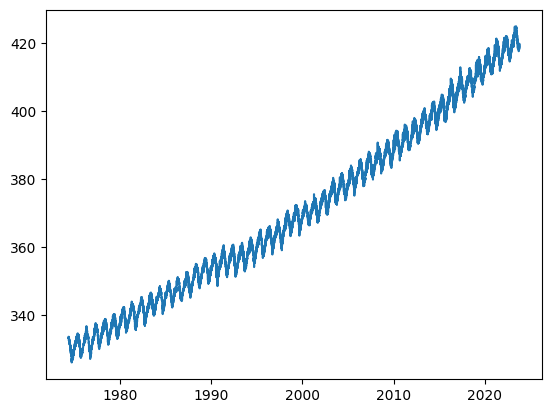

In [6]:
plt.plot(df["CO2 molfrac (ppm)"])

In [7]:
df.head(50)

,CO2 molfrac (ppm)
date,
1974-05-17,333.38
1974-05-18,333.11
1974-05-19,333.46
1974-05-20,333.64
1974-05-21,333.50
1974-05-22,333.21
1974-05-23,333.05
1974-05-26,333.32
1974-05-27,332.79


We're missing some dates 😱 Even though we don't have explicit `NaN` values, there are missing dates in our index. This is something you need to be __really__ careful about when working with TS data.

Let's calculate how many days we're missing. Subtract your start date (the `min()` of your `index`) from your end date (the `max()` of your `index`) to see how many days __should__ be between them.

In [8]:
missing = (df.index.max() - df.index.min()).days - len(df)

How does this differ from the number of days we __actually__ have in our DataFrame? Save your answer in the `missing` variable

In [9]:
missing

2861

In [10]:
from nbresult import ChallengeResult

result = ChallengeResult('missing',
                         missing = missing)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/arima-seasonal/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_missing.py::TestMissing::test_missing PASSED                        [100%]

============================== 1 passed in 0.00s ===============================


💯 You can commit your code:

git add tests/missing.pickle

git commit -m 'Completed missing step'

git push origin master



Let's see where the missing values actually are. Use `pd.date_range` to create the index we __should__ have. Then use the DataFrame's `.reindex()` function with this new date range to see where null values actually are in our first 100 entries!

In [11]:
# Create the full date range that should exist (daily frequency)
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')

# Reindex to expose missing dates as NaN rows
df = df.reindex(full_range)

# Check the first 100 entries to see the gaps
df[:100]

,CO2 molfrac (ppm)
1974-05-17,333.38
1974-05-18,333.11
1974-05-19,333.46
1974-05-20,333.64
1974-05-21,333.50
...,...
1974-08-20,329.07
1974-08-21,329.41
1974-08-22,NaN
1974-08-23,328.76


The simplest option here is to use the very handy `pd.interpolate("linear")` function to fill these in for us. Try running the cell below to see what it does:

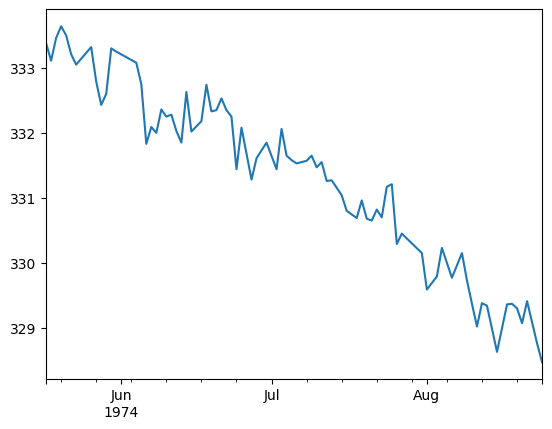

In [12]:
df["CO2 molfrac (ppm)"][:100].interpolate("linear").plot();

Interpolation uses a simple linear method to connect the points for us 😊 Of course this makes some imperfect assumptions, and we actually don't need daily samples - instead we'll `resample` our DataFrame on a monthly basis and try to model that. Try using the `.resample()` function to create a DataFrame containing the average for each month and name it `monthly`. See the [docs](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) here.

In [13]:
monthly = df.resample("ME").mean()
monthly

,CO2 molfrac (ppm)
1974-05-31,333.156923
1974-06-30,332.170400
1974-07-31,331.110000
1974-08-31,329.105769
1974-09-30,327.303182
...,...
2023-06-30,423.675172
2023-07-31,421.820952
2023-08-31,419.720952
2023-09-30,418.405556


If you __still__ have remaining null values, you can use `interpolate` to fill them. Plot your resampled data:

In [14]:
monthly = monthly.interpolate("linear")

<Axes: >

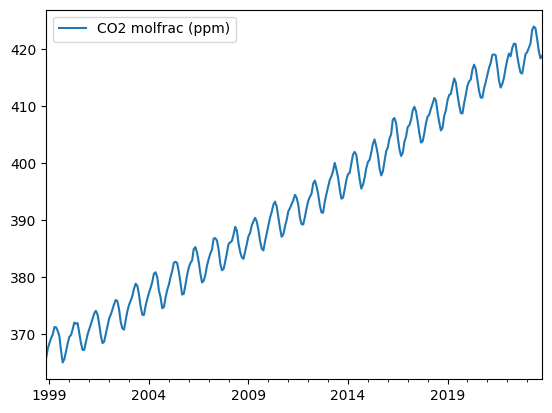

In [15]:
monthly[-300:].plot()

In [16]:
monthly["CO2 molfrac (ppm)"].iloc[0]

333.1569230769231

In [18]:
from nbresult import ChallengeResult

result = ChallengeResult('monthly',
                         monthly = monthly)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/arima-seasonal/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 2 items

test_monthly.py::TestMonthly::test_first_value PASSED                    [ 50%]
test_monthly.py::TestMonthly::test_missing PASSED                        [100%]

============================== 2 passed in 0.28s ===============================


💯 You can commit your code:

git add tests/monthly.pickle

git commit -m 'Completed monthly step'

git push origin master



## Train-Test Split

Now we need to split into training and test sets (we'll do an 80:20 split). Be careful when doing this - our sets need to be __continuous__!

In [19]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(monthly, test_size=0.2, shuffle=False)

Our data preparation is almost done. But before we start decomposing and modelling, we should establish a baseline to see how our model performs.

The typical baseline we'll choose is to predict the last available value for us. In our case, this is simply the last point in our `train` DataFrame.

Create a column called `naive_preds` in your `test` DataFrame and set it equal to the last available data point in `train`


In [20]:
naive_preds = train["CO2 molfrac (ppm)"].iloc[-1]
test["naive_preds"] = naive_preds

Once you've done that, calculate the mean absolute error between the two columns and set it as `baseline_mae`.

In [21]:
baseline_mae = (test["CO2 molfrac (ppm)"] - test["naive_preds"]).mean()
baseline_mae

14.503777783267303

In [22]:
from nbresult import ChallengeResult

result = ChallengeResult('baseline',
                         test = test,
                         baseline_mae = baseline_mae)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/arima-seasonal/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 3 items

test_baseline.py::TestBaseline::test_baseline_mae PASSED                 [ 33%]
test_baseline.py::TestBaseline::test_first_value PASSED                  [ 66%]
test_baseline.py::TestBaseline::test_missing PASSED                      [100%]

=============================== warnings summary ===============================
test_baseline.py::TestBaseline::test_first_value
  /Users/yaren/code/ds_projects/arima-seasonal/tests/test_baseline.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access

## Preparing for Modelling

With some Time Series models, we can throw our data at the model and hope it decomposes, stationarizes, and then models it for us (SARIMAX or TBATS are good examples of this), but instead we'll work step by step. Since we're not relying on a model to remove the seasonality and trend for us, we'll handle them ourselves.

Import the `seasonal_decompose` tool you saw in class and try both methods on your Time Series (both "multiplicative" and "additive").

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [24]:
additive_decomp = seasonal_decompose(train["CO2 molfrac (ppm)"], model="additive")
multiplicative_decomp = seasonal_decompose(train["CO2 molfrac (ppm)"], model="multiplicative")

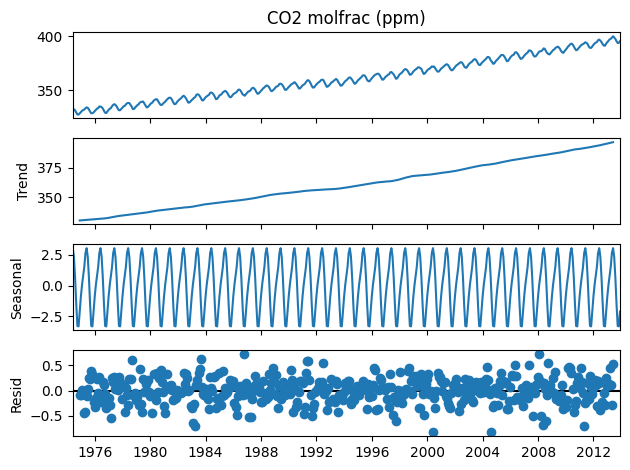

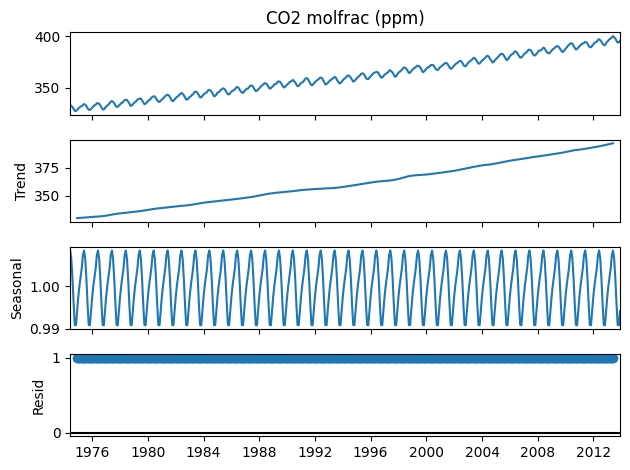

In [26]:
additive_decomp.plot();
multiplicative_decomp.plot();

Plot the residuals from both (access the `.resid` attribute) and remember - we want the one that looks as __unaffected__ by time as possible

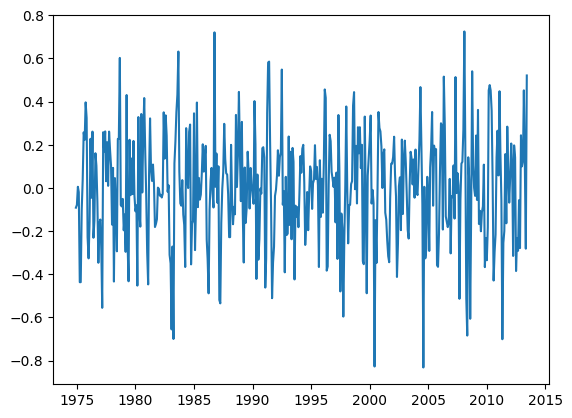

In [27]:
plt.plot(additive_decomp.resid)

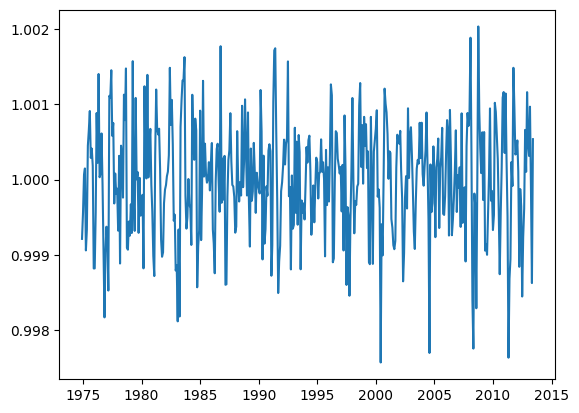

In [28]:
plt.plot(multiplicative_decomp.resid)

Since both look reasonably stationary, we'll choose the multiplicative model.

Now our strategy is to extract the seasonal component of our time series.

How can we do this? 🤔


First, create a column called `"seasonal_component"` in your `train` DataFrame filled with the `.seasonal` component of your time series.

Once you've done that, create a separate, smaller DataFrame containing only __one year__ of your seasonal components (i.e. the first 12 rows of your `seasonal components` column). This will be useful for us later. Name it `seasonal_one_year` and make sure you have a `"month"` column equal to the corresponding `index.month` (e.g. have a row with the January seasonal component and 1 next to it).

<img src = "https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/09-Time-Series/seasonal_component_one.png">

In [29]:
decomp = seasonal_decompose(train["CO2 molfrac (ppm)"], model="multiplicative")
train["seasonal_component"] = decomp.seasonal

In [32]:
seasonal_one_year = train[["seasonal_component"]].iloc[:12].copy()
seasonal_one_year["month"] = seasonal_one_year.index.month
seasonal_one_year

,seasonal_component,month
1974-05-31,1.008482,5
1974-06-30,1.006564,6
1974-07-31,1.001811,7
1974-08-31,0.995762,8
1974-09-30,0.990900,9
1974-10-31,0.990801,10
1974-11-30,0.994131,11
1974-12-31,0.997567,12
1975-01-31,1.000244,1
1975-02-28,1.002097,2


Since this comes from a multiplicative model, if we want to __remove__ this seasonal component, we'll need to __divide__ our original time series by these repeated (12-month cycle) values.

In [33]:
from nbresult import ChallengeResult

result = ChallengeResult('seasonal',
                         train = train,
                         seasonal = seasonal_one_year)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/arima-seasonal/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 2 items

test_seasonal.py::TestSeasonal::test_seasonal_column PASSED              [ 50%]
test_seasonal.py::TestSeasonal::test_seasonal_year_shape PASSED          [100%]

============================== 2 passed in 0.35s ===============================


💯 You can commit your code:

git add tests/seasonal.pickle

git commit -m 'Completed seasonal step'

git push origin master



Create a new column called `"seasonal_stripped"` that divides the value of your original time series by the seasonal component.

In [ ]:
# YOUR CODE HERE

Plot this new column:

In [ ]:
# YOUR CODE HERE

Does it look stationary yet? Discuss with your partner why or why not.

Our next task is to take this __de-seasonalized__ time series and make it stationary. Try using `.diff()` and see what it looks like. Then try diffing once more to see if you notice any change.

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

Both should look visually quite stationary, use the `adfuller` (Augmented Dickey-Fuller) test you saw in class to verify that each is stationary.

Note: when you `diff` you create null values in your DataFrame, you need to drop these to run the ADF test.

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

Both look reasonably stationary and it doesn't seem like we need excessive differencing (you can always try creating a twice-differenced time series later as well). Let's go ahead and plot our `acf` and `pacf` charts (make sure you drop any `null` values - these will break your ACF and PACF calculators) 😔

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

Take some time to talk through with your partner what these charts actually mean. Which one corresponds to your `p` parameter and which to your `q` parameter?

Now create a simple ARIMA model with appropriate order values for your `p`, `d`, and `q` values. Review the model summary.

In [ ]:
# YOUR CODE HERE

What do you notice about the summary? What are the most important features here?

It seems like we can trust our coefficients and we have an AIC of ~223. But was that the best model? Try using the `auto_arima` function to grid search different models and see which has the best AIC

In [ ]:
train

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

Save your best AIC score to `best_AIC`

In [ ]:
# YOUR CODE HERE

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('score',
                         aic_score = best_AIC)
result.write()
print(result.check())

Often, it can be hard to guess which model will best fit our data, so it's usually a good idea to grid-search and compare the AIC scores of our models 🧐 Here, it looks like a __(0,1,1)__ model gets a better AIC score (i.e. the MA components of our original model probably weren't improving our model likelihood that much!)

### Making Predictions (get ready for some Pandas work!)

Now that we have our best model, we want to generate some predictions and - importantly - some confidence intervals. Use your model to forecast for the length of your test set and make sure you return these intervals as well (use `return_conf_int = True`). Create a `preds_df` DataFrame with columns for `preds`, `upper` and `lower` bounds.

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('preds',
                         preds_df = preds_df)
result.write()
print(result.check())

Now plot these and see how they look compared to your `train` data

In [ ]:
# YOUR CODE HERE

Something looks a bit off, doesn't it? We're looking at three flat lines coming from something that clearly has seasonality. To account for this, we need to re-incorporate the seasonality component we extracted earlier!

Create a `month` column in your `preds_df` DataFrame and fill it with the month component of the index.

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

Now we can simply take the `seasonal_one_year` DataFrame we created earlier and merge it into our `preds_df`!

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE

In [ ]:
preds_df

Now you can create `full_preds`, `upper_conf` and `lower_conf` in the `preds_df` DataFrame as new columns (by multiplying your `preds`, `upper` __and__ `lower` columns by the seasonal component we now have in our `preds_df` DataFrame).

In [ ]:
# YOUR CODE HERE

Finally, to make plotting easier for us, set the index of your `preds_df` to be the same as the index of your `test` DataFrame (this should be pretty easy for us since they're the same length!)

In [ ]:
# YOUR CODE HERE

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('fullpreds',
                         preds_df = preds_df)
result.write()
print(result.check())

Now plot everything - the end of your `train` (e.g. the last 100 values), your full predictions, the upper and lower confidence bounds, and the actual values __and__ your baseline from your `preds_df` DataFrame!

In [ ]:
# YOUR CODE HERE

Our predictions look pretty good! We can see that the actual values are slightly higher than what we predicted but well within our confidence interval bounds for a full 10 years after we started predicting.

Why did our values fall below the actual values? Run the cell below to decompose the test data and look at the trend component 👀


In [ ]:
seasonal_decompose(test["CO2 molfrac (ppm)"]).plot();

We can see that there's a __slight uptick__ in all of our values before the normal (slightly shallower) trend takes over again around 2016-2018. This is a great example of something happening in our test dataset that we simply couldn't have predicted. We don't know why there was an increase in CO2 readings - and we couldn't predict for it.

❗ When modelling with Time Series, __we can't magically predict the future__. What we're trying to do is accurately capture the patterns of the past and then extend them.

- Often, your raw predictions (without the seasonal component) will look like a rather boring flat line 🙄 (like our current initial predictions do) but this is something we expect
- Much of the value we get from doing Time Series analysis lies in being able to __quantify__ our trends, seasonal components, and confidence intervals so we can make well-informed decisions ✅

Finally, let's quickly quantify how much better our model is than our baseline. Calculate the mean absolute error between your `preds` (with their seasonal components) and the actual values. See if your `model_mae` is lower than the original `baseline_mae`.

In [ ]:
model_mae = (test["CO2 molfrac (ppm)"] - preds_df["full_preds"]).mean()

In [ ]:
# YOUR CODE HERE

Our final MAE should be __much__ better than our original baseline. Great work 🥳 